# $ b \to s \ell^+ \ell^-$ brach cuts of perturbative NLO results

## 1 Preliminaries

### 1.1 Import modules, link directories, define glabal variables

In [19]:
import eos
import numpy as np
import matplotlib.pyplot as plt
import os
import cmath
eos.__version__

'1.0.19'

### 1.2 Functions

In [20]:
eos.Parameters()["sb::mu"]

$$\mu^{b \to s}$$,(eos.Parameter)
current value,4.2
default value,4.2


In [21]:
eos.Parameters()["mass::b(MSbar)"]

$$\overline{m}_b(\overline{m}_b)$$,(eos.Parameter)
current value,4.18
default value,4.18


In [29]:
def FF(FF_name, diag_name, s_real, s_imag):
    
    diagram = diag_name # options "0", "Qc", "Qsb", "a", "b", "c", "d", "e", "ctQc", "ctQs", "ctQb", "all" 
    q2_real = s_real * 4.18**2
    q2_imag = s_imag * 4.18**2

    p = eos.Parameters.Defaults()
    p.set("mass::c", 4.18 * 0.29)
    p.set("sb::mu", 4.18)
    
    # NOTE: keys must match the observable's parameter names used in make_observable
    kinematics = {"Re{q2}": q2_real, "Im{q2}": q2_imag}

    # build observable names with literal braces around the F+number, e.g. Re{F27}
    re_name = "b->s::Re{{{}}}(Re{{q2}},Im{{q2}})".format(f"F{FF_name}")
    im_name = "b->s::Im{{{}}}(Re{{q2}},Im{{q2}})".format(f"F{FF_name}")

    real_part = eos.Observable.make(re_name, p, eos.Kinematics(kinematics), eos.Options({"contribution": diagram})).evaluate()
    imag_part = eos.Observable.make(im_name, p, eos.Kinematics(kinematics), eos.Options({"contribution": diagram})).evaluate()

    return real_part + 1j * imag_part

In [30]:
def plot_FF(FF_name, diag_name, reim, s_imag_values, s_real_range=(-2, 2), num_points=40, y_range=None):
    # Generate values for s in the specified range
    s_real_values = np.linspace(s_real_range[0], s_real_range[1], num_points)

    # Iterate over each s_imag value
    for i, s_imag in enumerate(s_imag_values):
        # Calculate corresponding function values
        if reim == "Re":
            function_values = np.real([FF(FF_name, diag_name, s, s_imag) for s in s_real_values])
        elif reim == "Im":
            function_values = np.imag([FF(FF_name, diag_name, s, s_imag) for s in s_real_values])

        # Choose markers based on the index (i)
        markers = ['x', '+']
        marker = markers[i]

        # Plot the function for the current s_imag value with the chosen marker
        label = fr'$F_{{{FF_name}}}^{{\mathrm{{{diag_name}}}}}(\mathrm{{Im}}(s)={s_imag})$'
        plt.scatter(s_real_values, function_values, label=label, marker=marker)

    plt.xlabel('s')
    plt.ylabel(fr'$F_{{{FF_name}}}^{{\mathrm{{{diag_name}}}}}$')
    plt.legend()

    # Set custom plot ranges for x and y axes
    plt.xlim(s_real_range[0], s_real_range[1])

    if y_range is not None:
        plt.ylim(y_range[0], y_range[1])

    plt.grid(True)
    plt.show()


In [31]:
def plot_2dFF(FF_name, diag_name, real_range=(-0.5, 2.0), imag_range=(-0.75, 0.25), num_points=100, part=np.angle):
    RealParts = np.linspace(real_range[0], real_range[1], num_points)
    ImagParts = np.linspace(imag_range[0], imag_range[1], num_points)
    #X, Y = np.meshgrid(RealParts, ImagParts)

    Z = np.array([[part(FF(FF_name, diag_name, x, y)) for y in ImagParts] for x in RealParts]).T

    fig, ax = plt.subplots()

    p = ax.pcolor(RealParts, ImagParts, Z, cmap='inferno')
    fig.colorbar(p, ax=ax)
    ax.set_xlabel(fr'Re $q^2/m_b^2$')
    ax.set_ylabel(fr'Im $q^2/m_b^2$')
    ax.set_title(fr'phase of $F_{{{FF_name}}}^{{\mathrm{{{diag_name}}}}}$')

    # save plot 
    real_range_str = f'{real_range[0]:.2f}_{real_range[1]:.2f}'.replace('.', 'p')
    if not os.path.exists(f'plots/{real_range_str}'):
        os.makedirs(f'plots/{real_range_str}')
    
    plot_filename = f'plots/{real_range_str}/phase_F{FF_name}_{diag_name}.png'
    plt.savefig(plot_filename)

    plt.show()

In [32]:
def plot_2dFF(FF_name, diag_name, real_range=(-0.5, 2.0), imag_range=(-0.75, 0.25), num_points=100, part=np.angle, flat_scale = False):
    RealParts = np.linspace(real_range[0], real_range[1], num_points)
    ImagParts = np.linspace(imag_range[0], imag_range[1], num_points)

    Z = np.empty((len(ImagParts), len(RealParts)))

    threshold = np.abs(200*part(FF(FF_name, diag_name, -1, 1e-8)))
    print(f'threshold={threshold}')

    power = 1

    for i, y in enumerate(ImagParts):
        for j, x in enumerate(RealParts):
            value = part(FF(FF_name, diag_name, x, y))
            if flat_scale is False:
                Z[i, j] = value
            else:
                if 0 < value < threshold:
                    Z[i, j] = pow(value, power)
                elif -threshold < value < 0:
                    Z[i, j] = -pow(-value, power)
                elif value > threshold:
                    Z[i, j] = threshold
                elif value < -threshold:
                    Z[i, j] = -threshold

    fig, ax = plt.subplots()

    p = ax.pcolor(RealParts, ImagParts, Z, cmap='PiYG')
    fig.colorbar(p, ax=ax)
    ax.set_xlabel(fr'Re $q^2/m_b^2$')
    ax.set_ylabel(fr'Im $q^2/m_b^2$')
    ax.set_title(fr'{part.__name__} of $F_{{{FF_name}}}^{{\mathrm{{{diag_name}}}}}$')

    # save plot 
    real_range_str = f'{real_range[0]:.2f}_{real_range[1]:.2f}'.replace('.', 'p')
    if not os.path.exists(f'plots/{real_range_str}'):
        os.makedirs(f'plots/{real_range_str}')
    
    plot_filename = f'plots/{real_range_str}/{part.__name__}_F{FF_name}_{diag_name}.png'
    plt.savefig(plot_filename)

    plt.show()

In [33]:
def plot_2dfun(funct, real_range=(-0.5, 2.0), imag_range=(-0.75, 0.25), num_points=100, title=None):
    RealParts = np.linspace(real_range[0], real_range[1], num_points)
    ImagParts = np.linspace(imag_range[0], imag_range[1], num_points)

    Z = np.array([[np.angle(funct(x + y*1j)) for y in ImagParts] for x in RealParts]).T

    fig, ax = plt.subplots()

    p = ax.pcolor(RealParts, ImagParts, Z, cmap='viridis')
    fig.colorbar(p, ax=ax)
    ax.set_xlabel(fr'Re $q^2/m_b^2$')
    ax.set_ylabel(fr'Im $q^2/m_b^2$')
    if title is not None: 
        ax.set_title(fr'${title}$')
    
    plt.show()

### 1.9 Stop evaluation

In [34]:
raise SystemExit("Stop evaluation here")

SystemExit: Stop evaluation here

## 2 Evaluate

### 2.1 Reproduce section template of 059 JV020420CL9

In [43]:
FF("27", "Qc", -1, 1e-8)

(2.4101714015313576+0.09614342868188488j)

In [44]:
FF("29", "Qc", -1, 1e-8)

(4.554412926335218-0.023677771603506627j)

In [45]:
FF("17", "Qc", -1, 1e-8)

(-0.4016952335885596-0.01602390478031415j)

In [46]:
FF("19", "Qc", -1, 1e-8)

(-1.8045580362039808+0.0039462569122003036j)

### 2.2 Reproduce some replacements in 036 NG080419CL3

In [47]:
FF("17", "Qc", 0.6, 1e-8)

(-0.8358660197621702-0.2571282001387084j)

In [48]:
FF("17", "Qc", 0.6, -1e-8)

(-1.0541893848742623-1.5503897347031586j)

### 2.3 Create a list of Mathematica replacements

In [49]:
FF("17", "Qc", 0.2, 1e-8)

(-0.6548070266046626-0.09593113532863583j)

In [50]:
FF("17", "all", 0.05, -1e-8)

(-0.7009991899830232-0.08328083098527968j)

In [51]:
def generate_FFlist():

    def generate_numbers(x, y, d):
  
    #Generate a list of numbers with min value x, max value y, and z difference between each number.

        if x >= y:
            return []
    
        result = []
        current = x
        while current <= y:
            result.append(round(current, 4))
            current += d
    
        return result

    list_s_real = generate_numbers(0.025, 0.400, 0.025)

    list_FF_name = ["17", "27", "19", "29"]
    list_diag_name = ["all"] #Qc, "Qsb", "a", "b", "c", "d", "e", "ctQc", "ctQs", "ctQb", "all"
    list_s_imag = [-1e-8] #, [1e-8, -1e-8]
    
    #removed imaginary part from the output because doesn't change anything below threshold
    formatted_list = [f'FFp["{FF_name}", "{diag_name}", {s_real}*mb^2] :> {result.real} + {result.imag}*I,' 
                  for diag_name in list_diag_name
                  for s_imag in list_s_imag
                  for s_real in list_s_real
                  for FF_name in list_FF_name
                  for result in [FF(FF_name, diag_name, s_real, s_imag)]]

    return formatted_list


result_FFlist = generate_FFlist()
for item in result_FFlist:
    print(item)

FFp["17", "all", 0.025*mb^2] :> -0.6915643559506421 + -0.07944607852448275*I,
FFp["27", "all", 0.025*mb^2] :> 4.149386135703852 + 0.47667647114689654*I,
FFp["19", "all", 0.025*mb^2] :> -12.046066495971017 + -0.14429450934946103*I,
FFp["29", "all", 0.025*mb^2] :> 2.6635436766269516 + 0.8657689163506562*I,
FFp["17", "all", 0.05*mb^2] :> -0.7009991899830232 + -0.08328083098527968*I,
FFp["27", "all", 0.05*mb^2] :> 4.205995139898139 + 0.49968498591167804*I,
FFp["19", "all", 0.05*mb^2] :> -12.937352847890033 + -0.20181548230161783*I,
FFp["29", "all", 0.05*mb^2] :> 3.0863548890056847 + 1.2108949804625335*I,
FFp["17", "all", 0.075*mb^2] :> -0.7104445667977286 + -0.08688828881519373*I,
FFp["27", "all", 0.075*mb^2] :> 4.262667400786372 + 0.5213297328911622*I,
FFp["19", "all", 0.075*mb^2] :> -13.909300151369413 + -0.24415055718366088*I,
FFp["29", "all", 0.075*mb^2] :> 3.3668118090905224 + 1.4649057066602689*I,
FFp["17", "all", 0.1*mb^2] :> -0.7198345123207769 + -0.0903293075540038*I,
FFp["27", "a

### 2.9 Stop evaluation

In [52]:
raise SystemExit("Stop evaluation here")

SystemExit: Stop evaluation here

## 3 Plots

### 3.1 Reproduce plots of 1912.09099

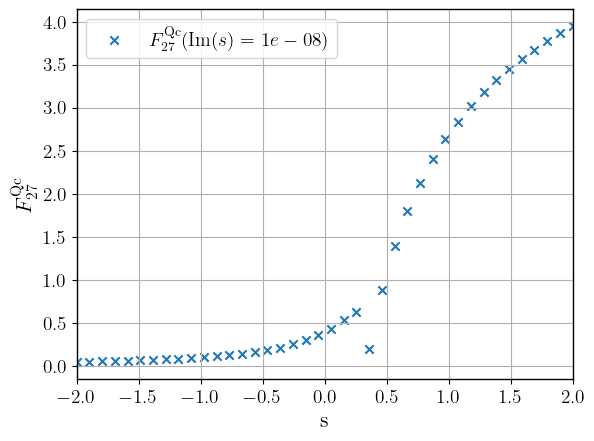

In [53]:
plot_FF("27", "Qc", "Im", {1e-8})

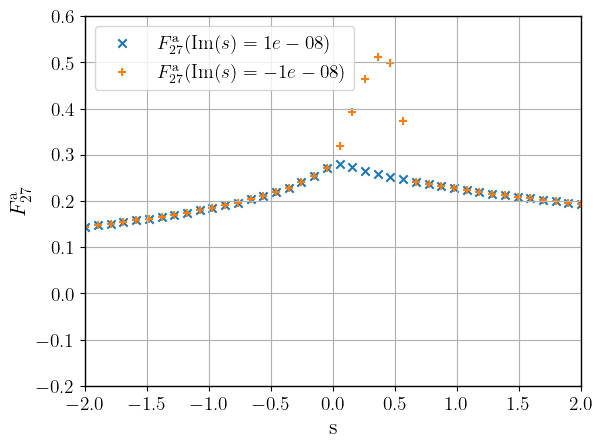

In [55]:
plot_FF("27", "a", "Re", {-1e-8, 1e-8}, y_range=(-0.2,0.6))

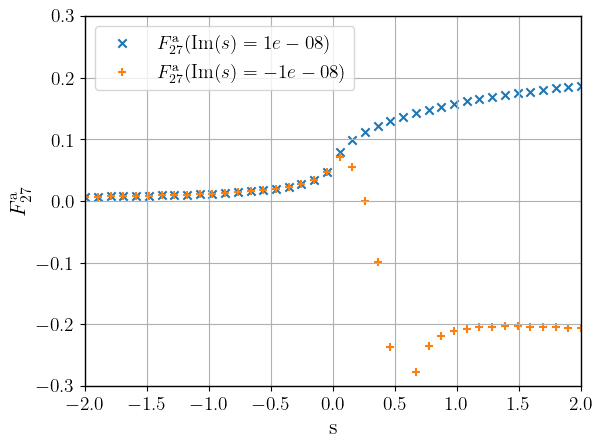

In [56]:
plot_FF("27", "a", "Im", {-1e-8, 1e-8}, y_range=(-0.3,0.3))

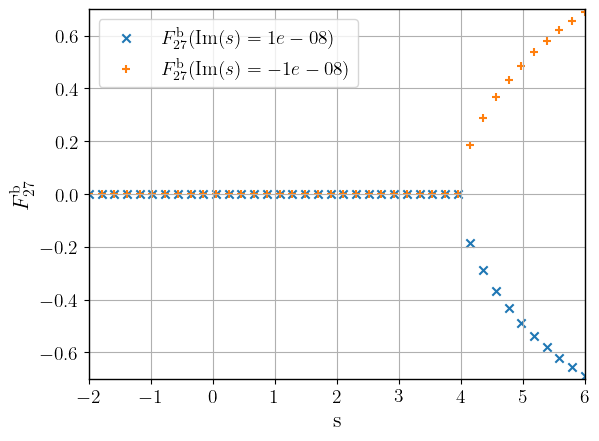

In [57]:
plot_FF("27", "b", "Im", {-1e-8, 1e-8}, s_real_range=(-2, 6), y_range=(-0.7,0.7))

### 3.2 2D histogram

#### 3.2.1 test

In [58]:
stmp= -6.7
print(
    np.real(FF("17", "Qc", stmp, 1e-8)),
    np.imag(FF("17", "Qc", stmp, 1e-8)),
    np.arctan(np.imag(FF("17", "Qc", stmp, 1e-8))/np.real(FF("17", "Qc", stmp, 1e-8))) - np.pi,
    np.angle(FF("17", "Qc", stmp, 1e-8))
)

-0.0021208030781131454 -0.0010511672910058732 -2.6814344101040644 -2.681434410104065


In [59]:
np.real(FF("17", "Qc", -8, 1e-8))

0.04531682274735894

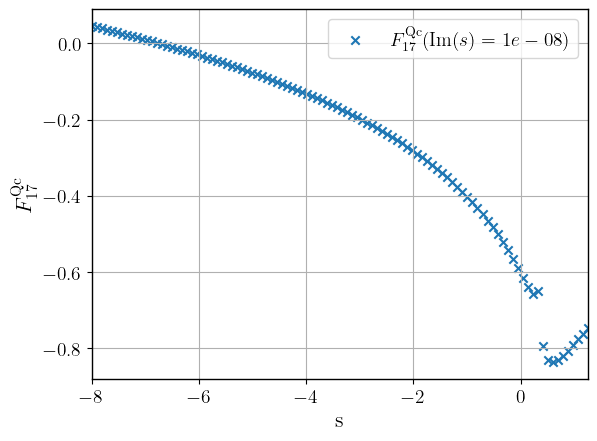

In [60]:
plot_FF("17", "Qc", "Re", {1e-8}, s_real_range=(-8, 1.25), num_points=100)

threshold=80.33904671771191


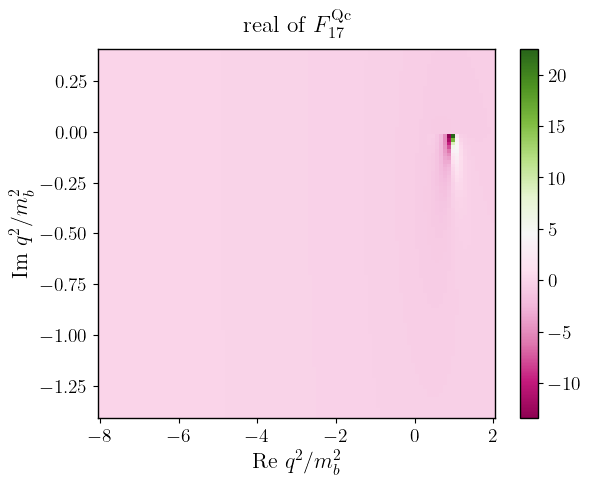

In [61]:
plot_2dFF("17", "Qc", num_points=100, real_range=(-8, 2.0), imag_range=(-1.4, 0.4), part=np.real, flat_scale=True)

threshold=3.204780956063052


/tmp/ipykernel_2525530/722777271.py:29: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='PiYG')


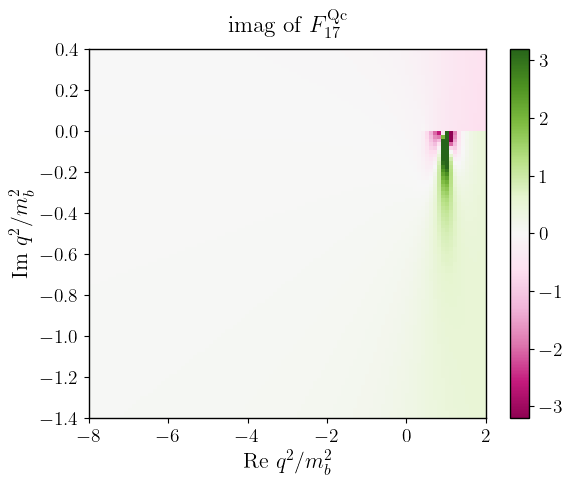

: 

: 

In [ ]:
plot_2dFF("17", "Qc", num_points=100, real_range=(-8, 2.0), imag_range=(-1.4, 0.4), part=np.imag, flat_scale=True)

#### 3.2.2 Range $s\in [-8,2]$

In [ ]:
for i in ["17","27","19","29"]:
        for j in [np.real, np.imag, np.abs, np.angle]: #"ctQb"
            plot_2dFF(i, "Qc", num_points=100, real_range=(-8.0, 2.0), part=j)

KeyboardInterrupt: 

: 

: 

/tmp/ipykernel_2525530/3430960412.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='hsv')


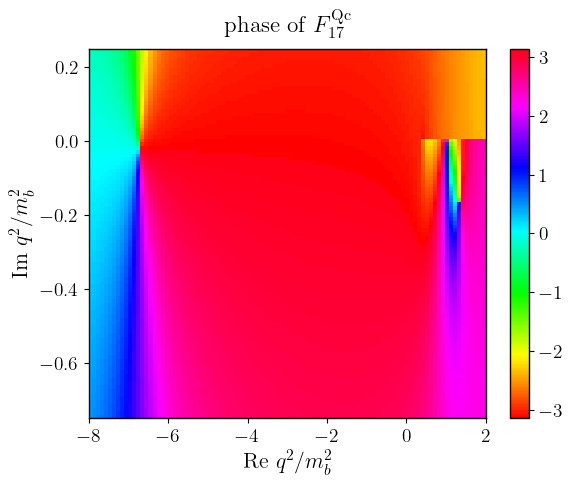

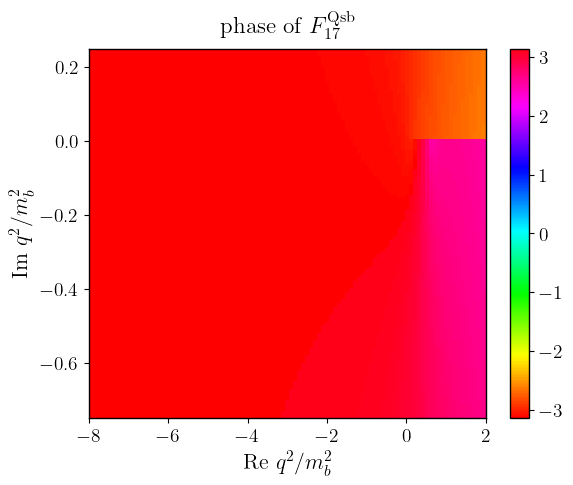

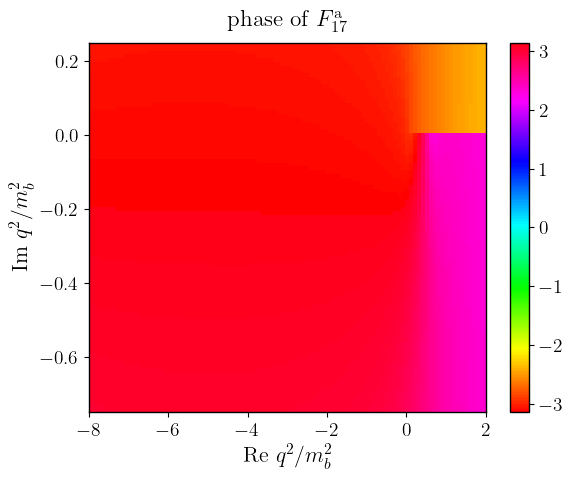

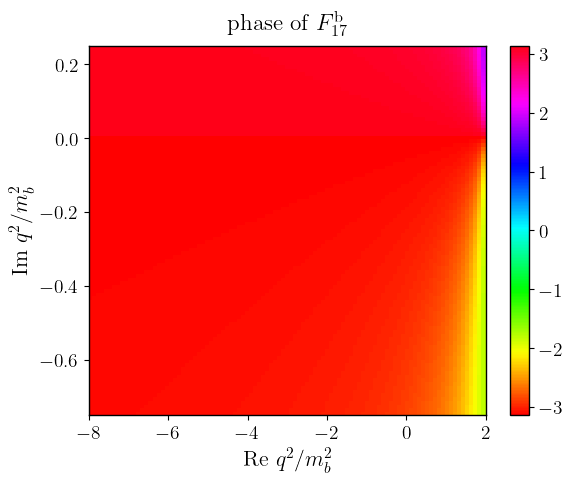

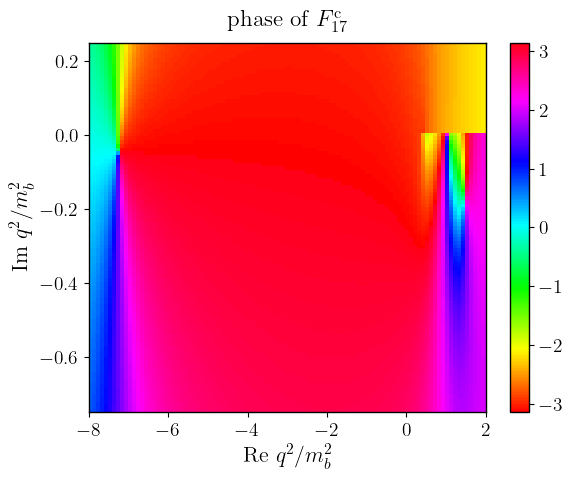

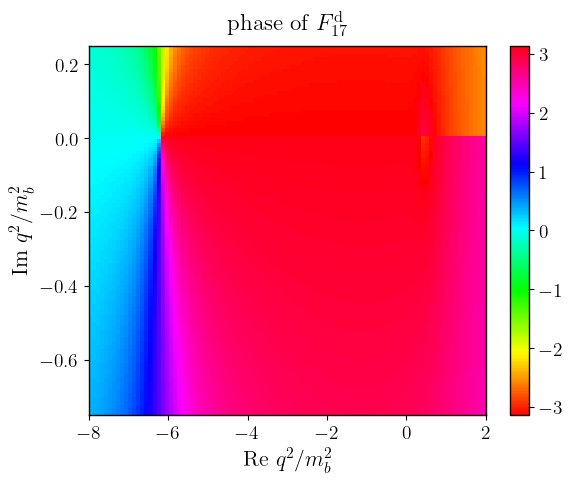

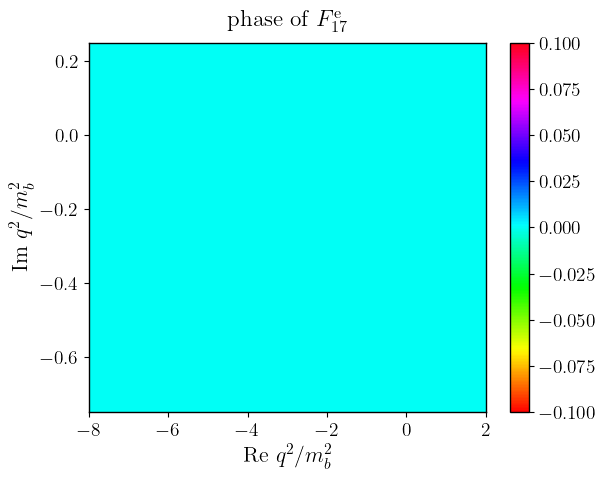

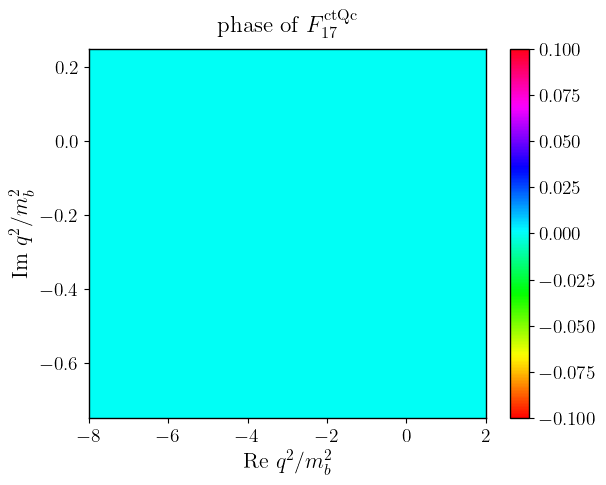

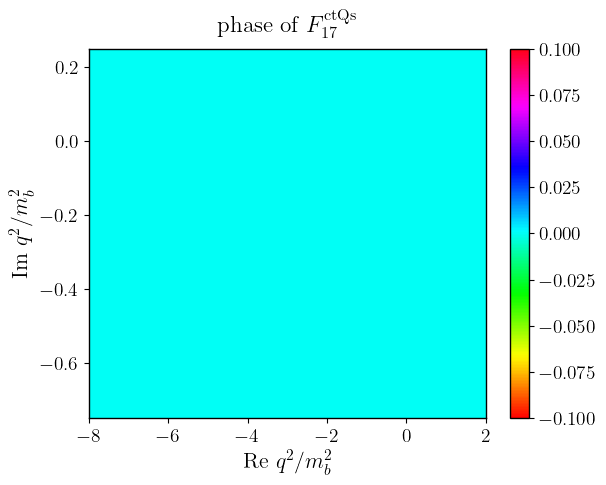

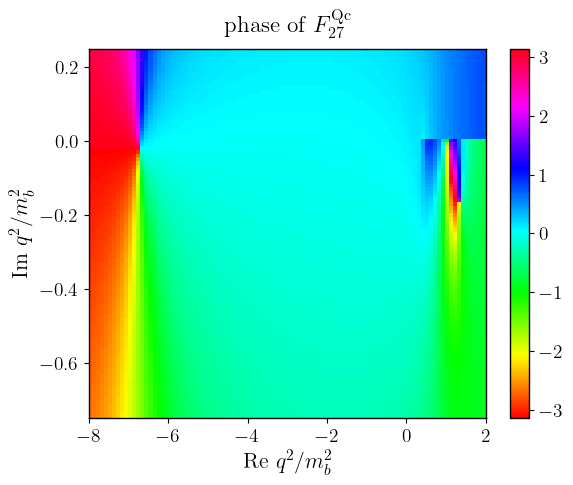

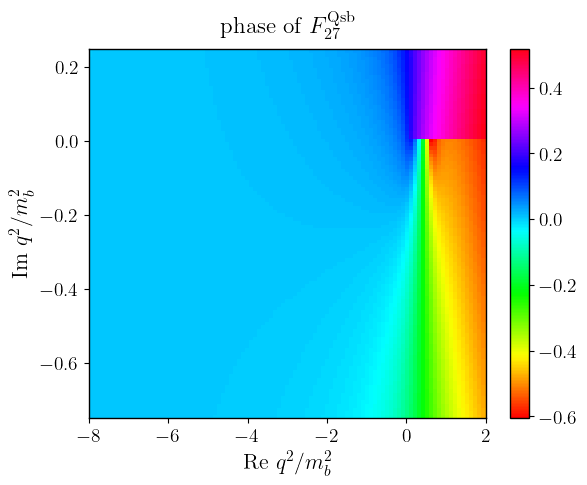

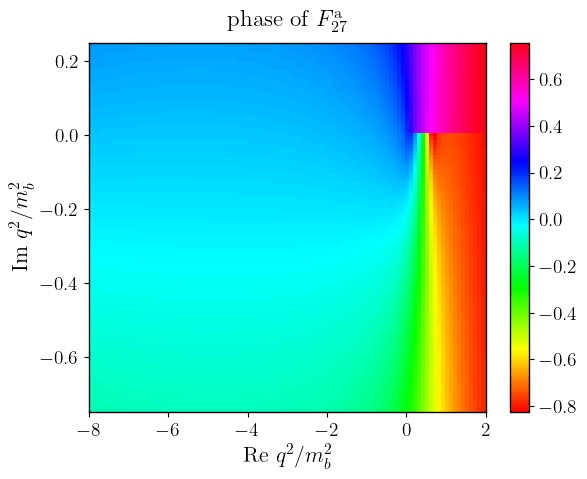

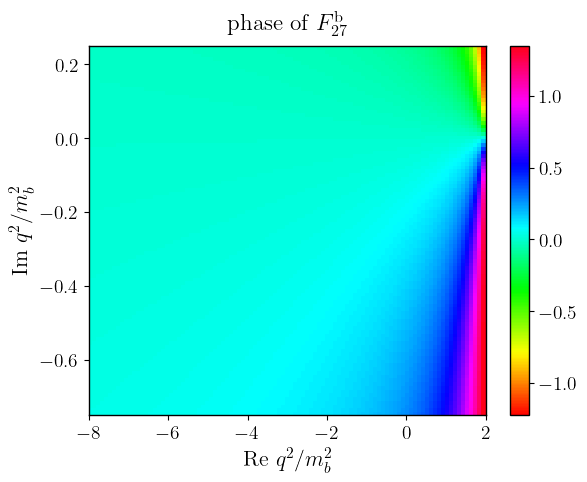

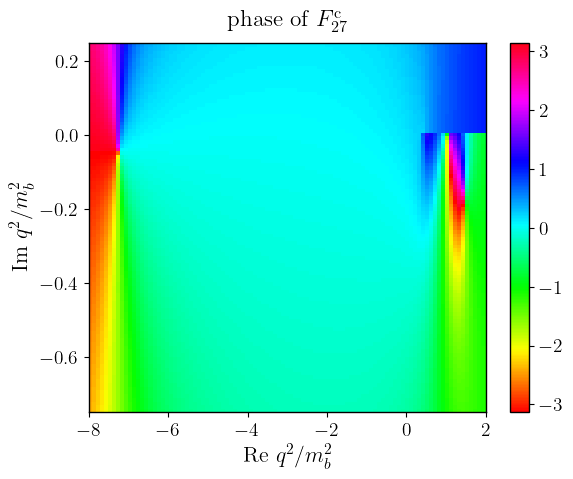

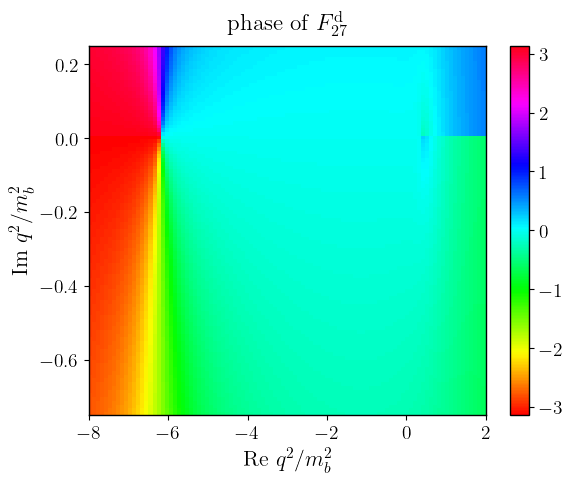

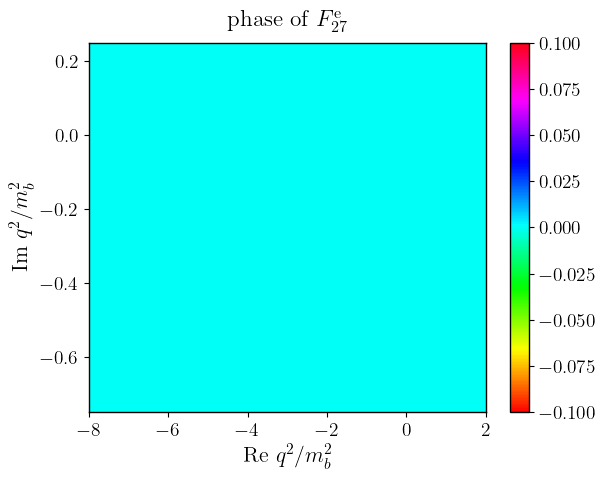

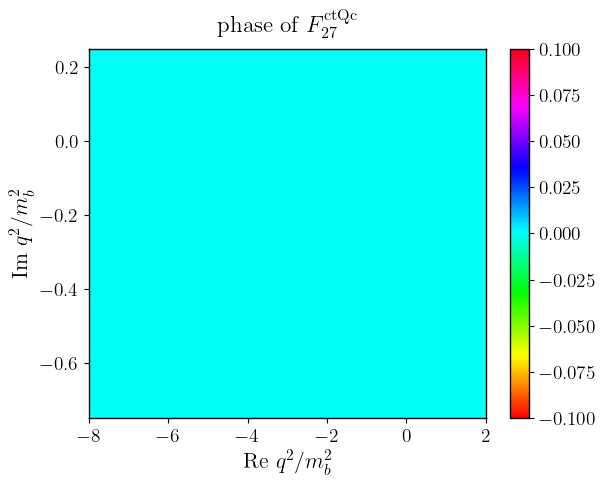

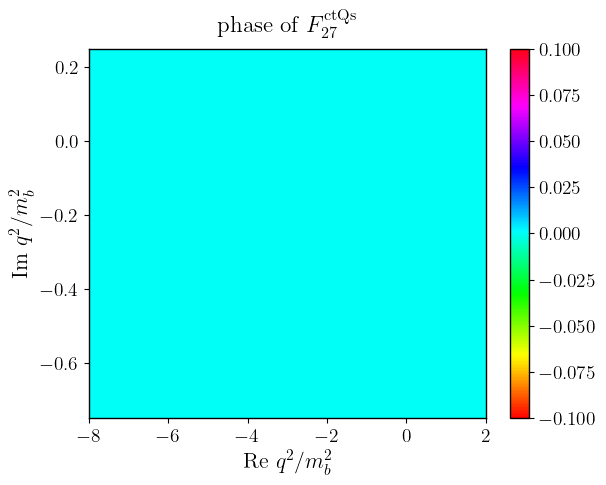

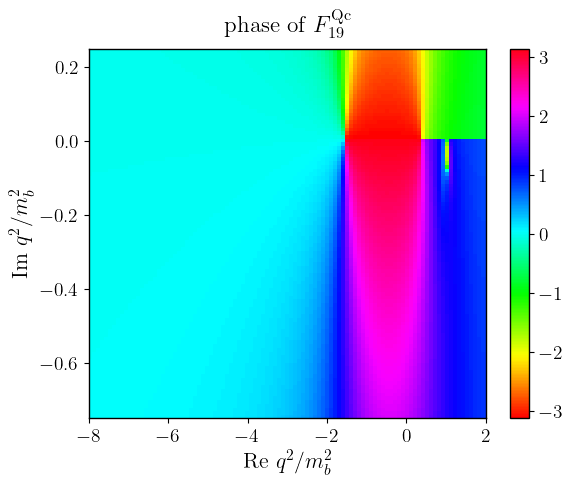

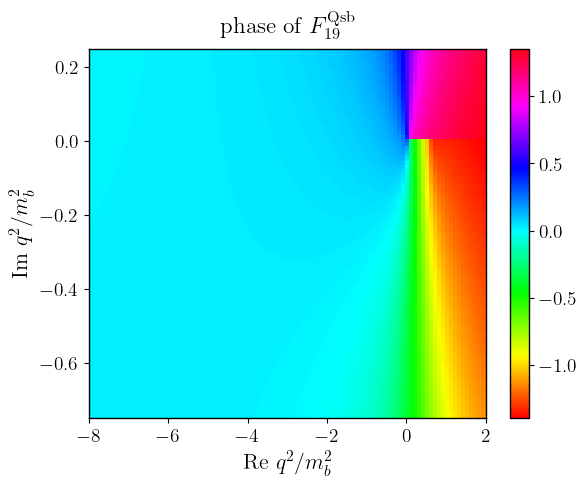

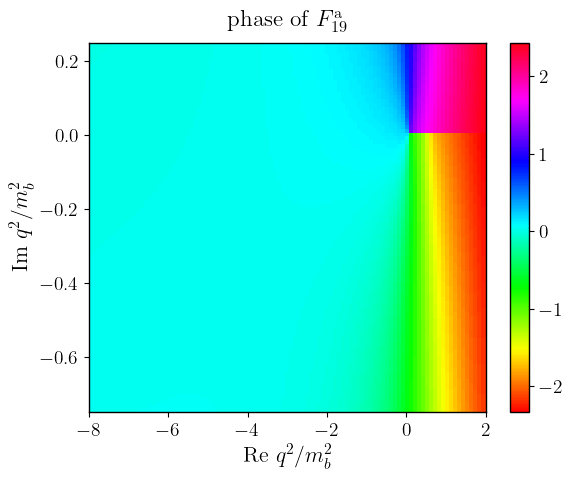

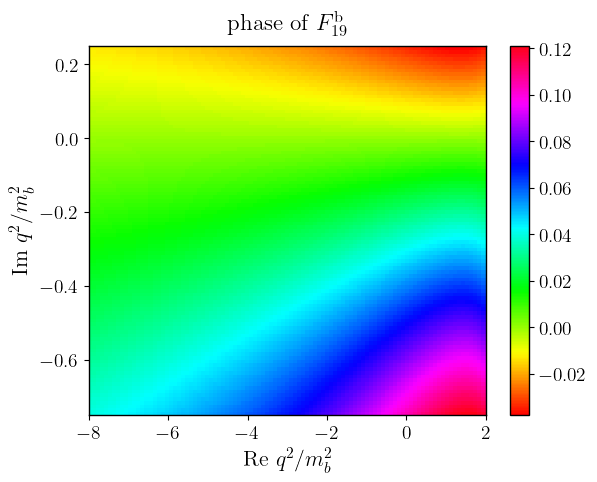

/tmp/ipykernel_2525530/3430960412.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='hsv')


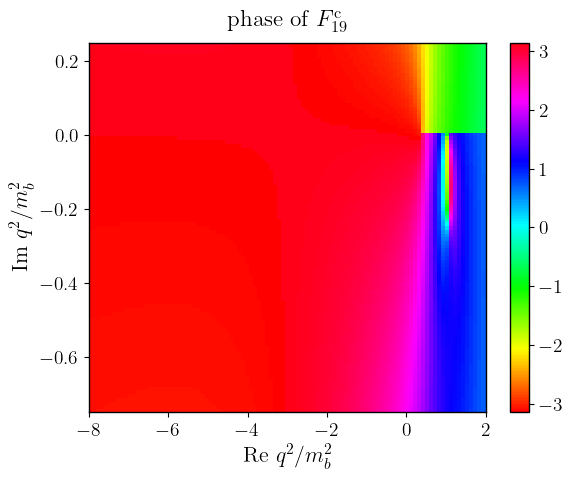

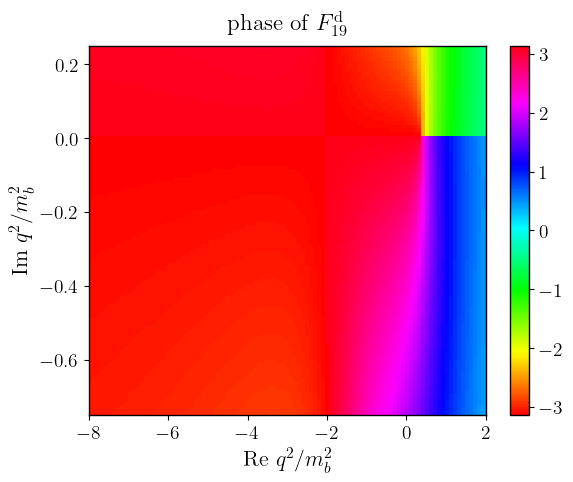

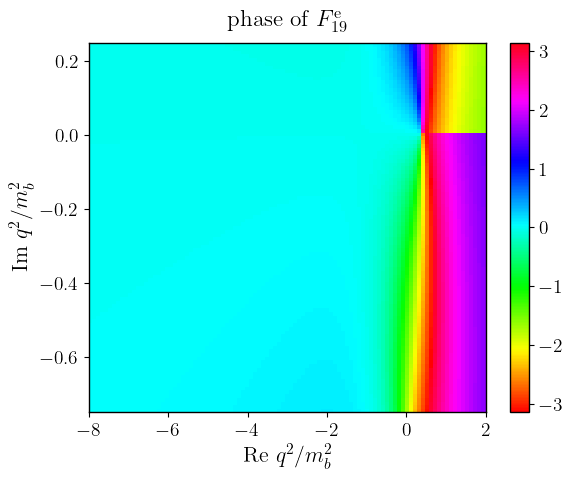

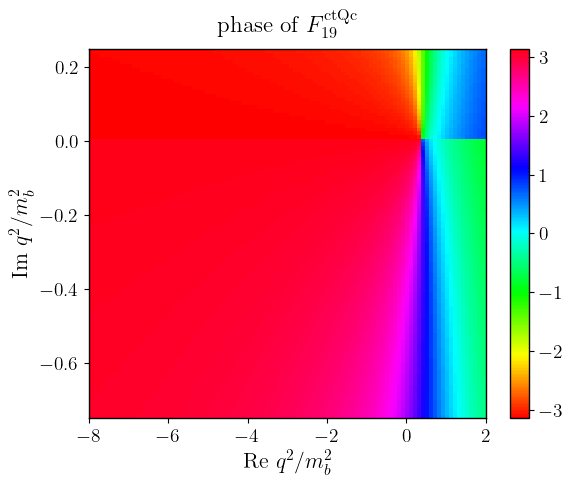

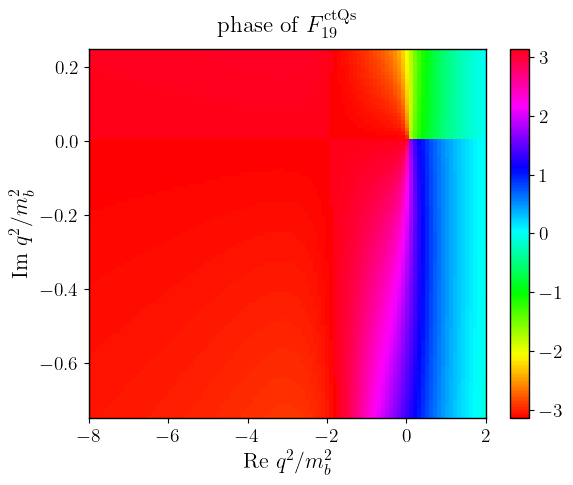

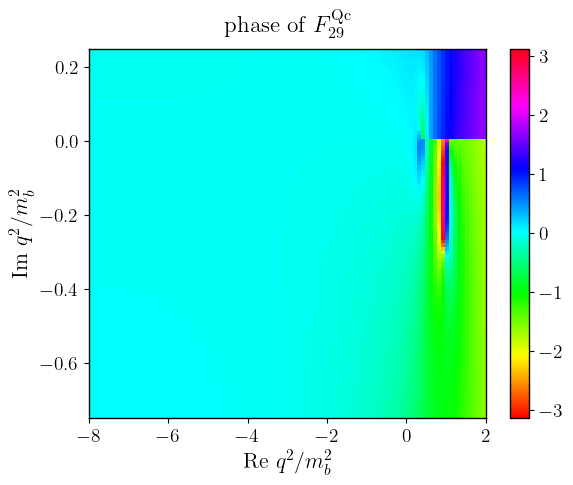

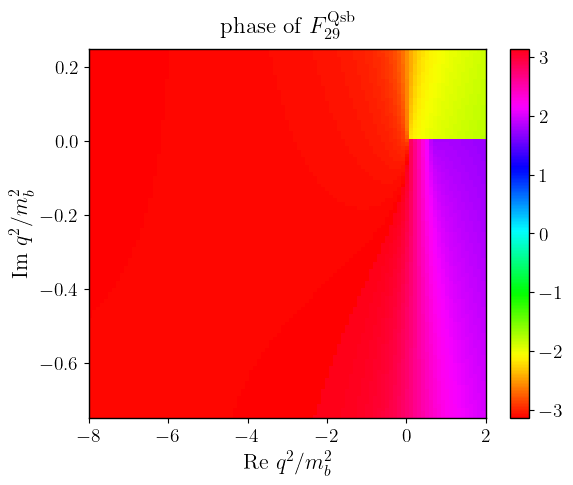

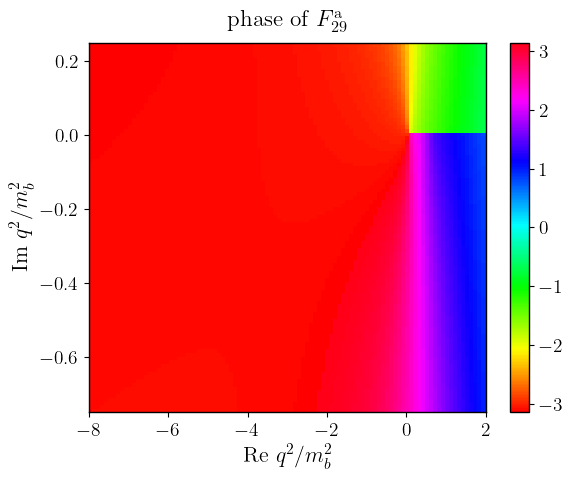

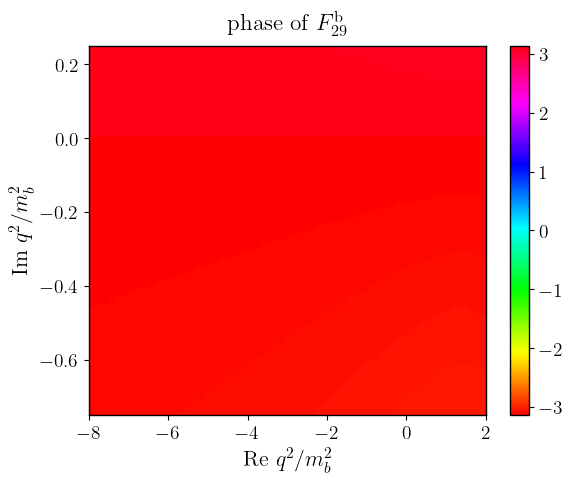

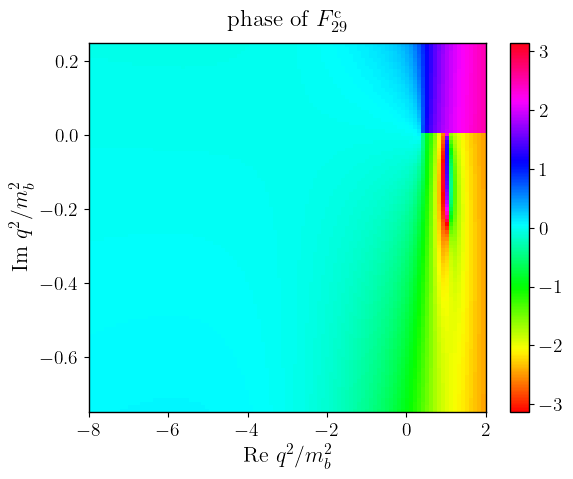

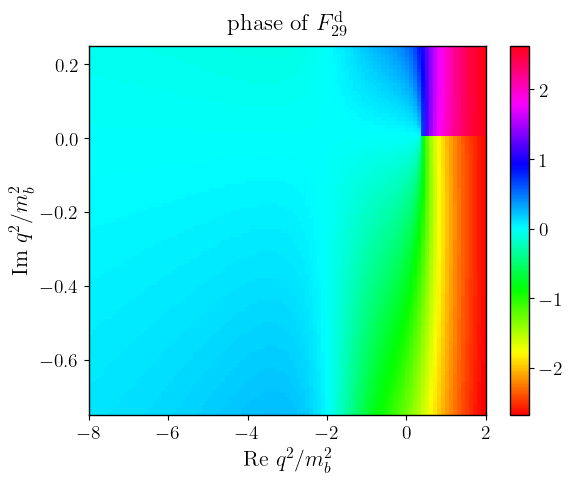

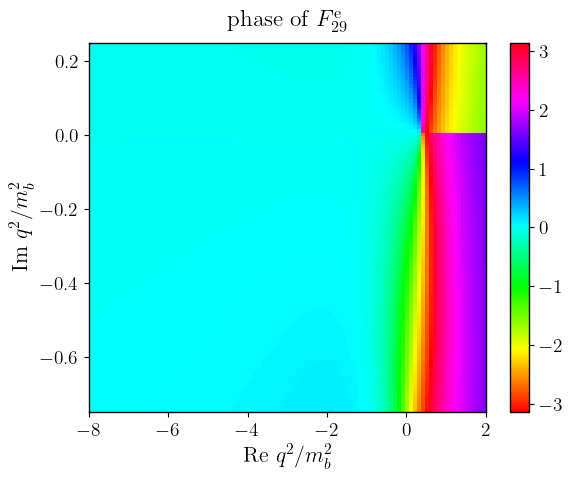

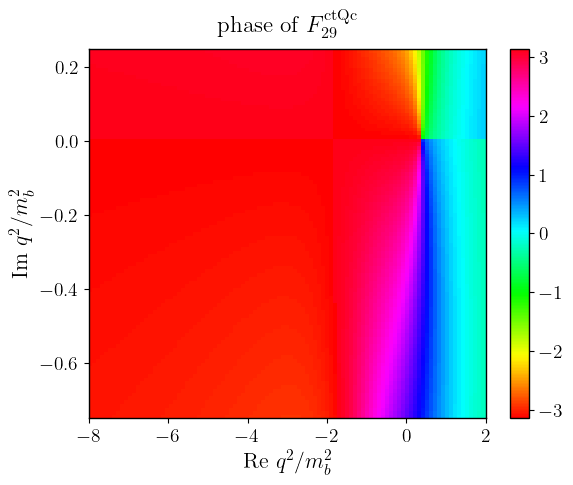

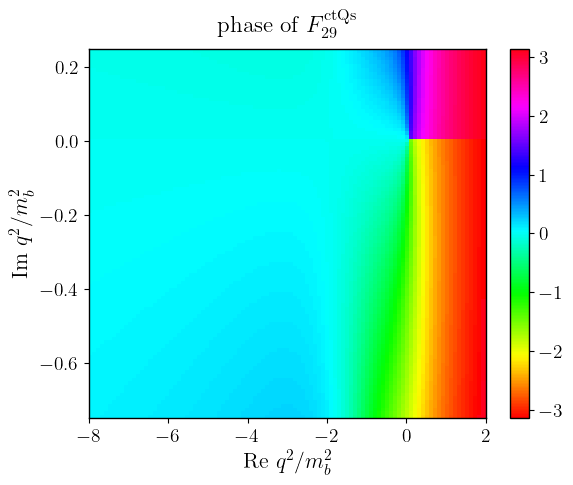

: 

: 

In [ ]:
for i in ["17","27","19","29"]:
        for j in ["Qc", "Qsb", "a", "b", "c", "d", "e", "ctQc", "ctQs"]: #"ctQb"
            plot_2dFF(i, j, num_points=100, real_range=(-8.0, 2.0))

#### 3.2.3 Range $s\in [0,2]$

/tmp/ipykernel_2525530/3430960412.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='hsv')


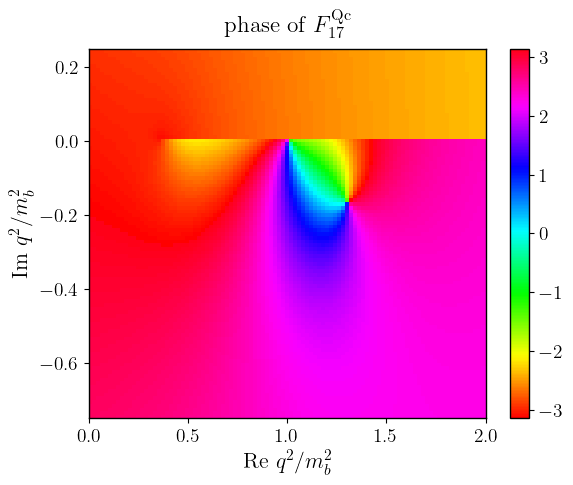

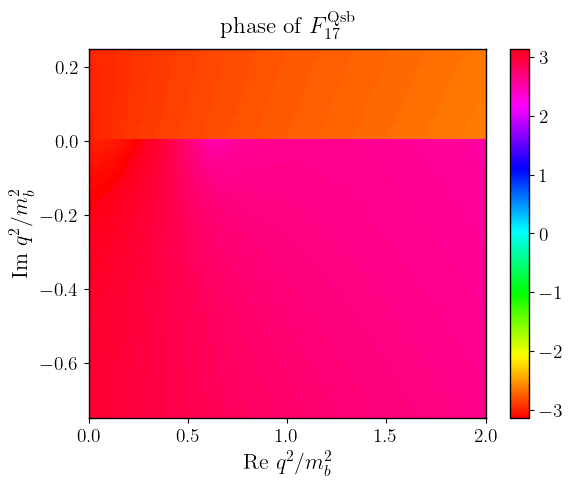

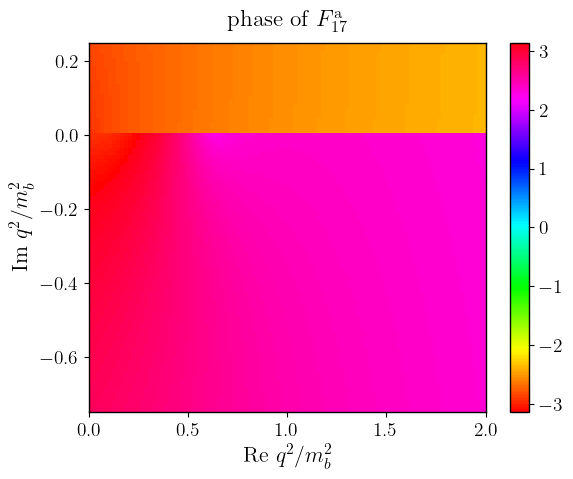

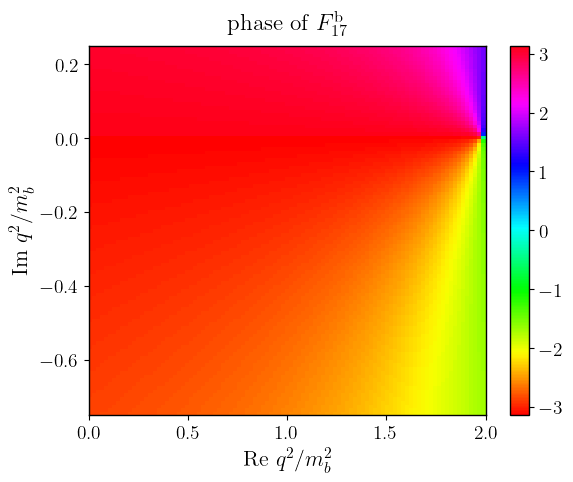

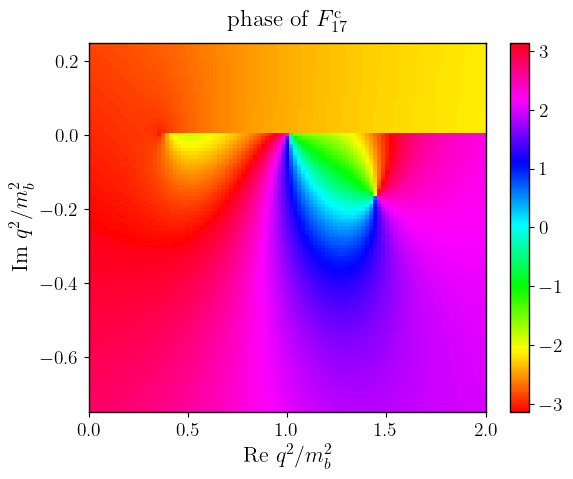

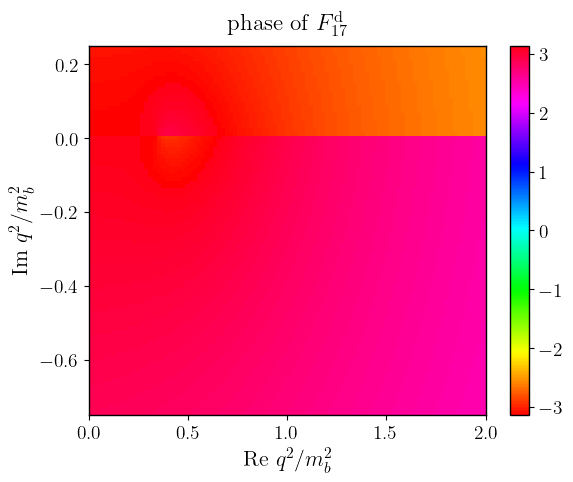

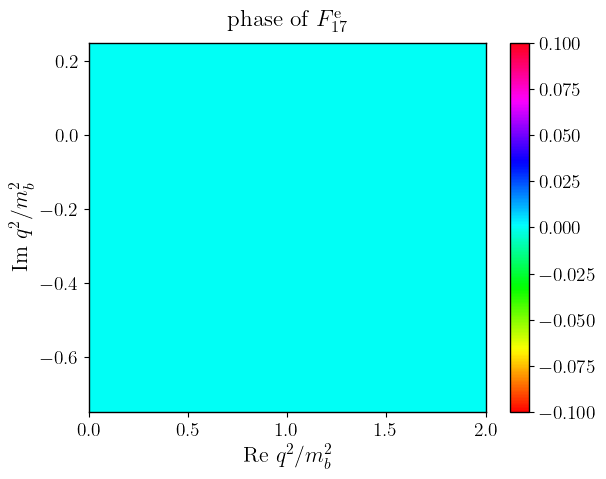

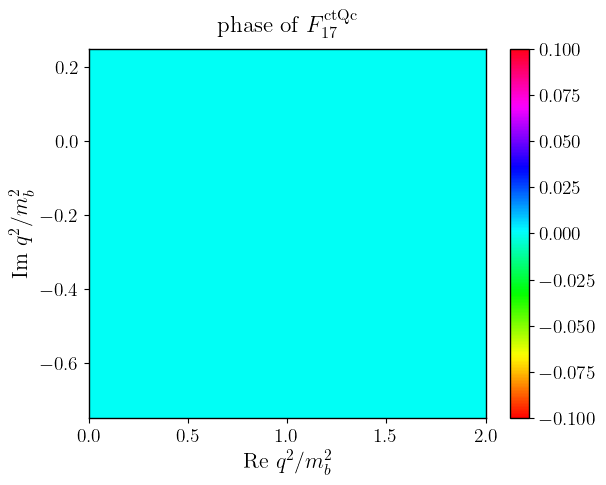

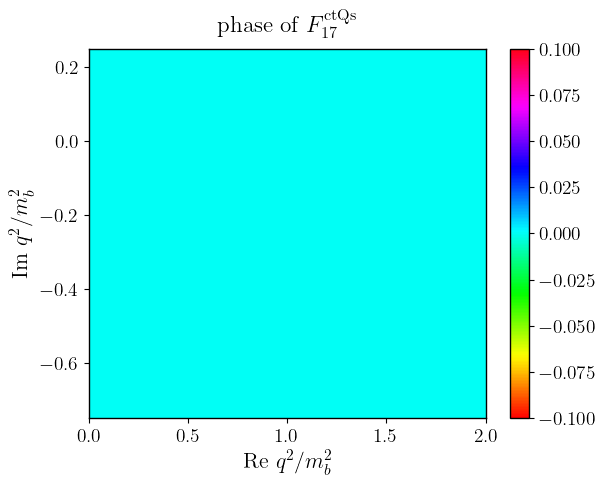

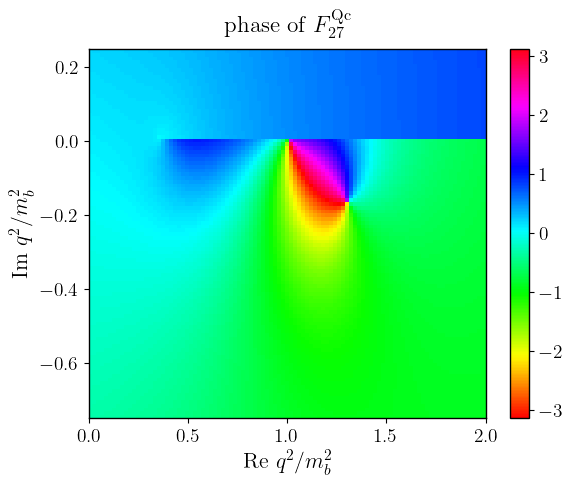

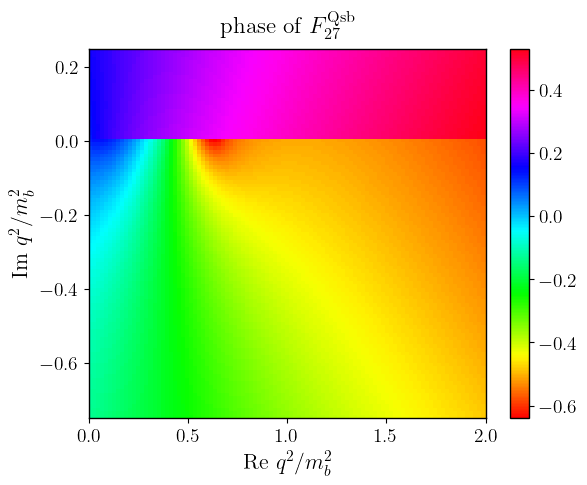

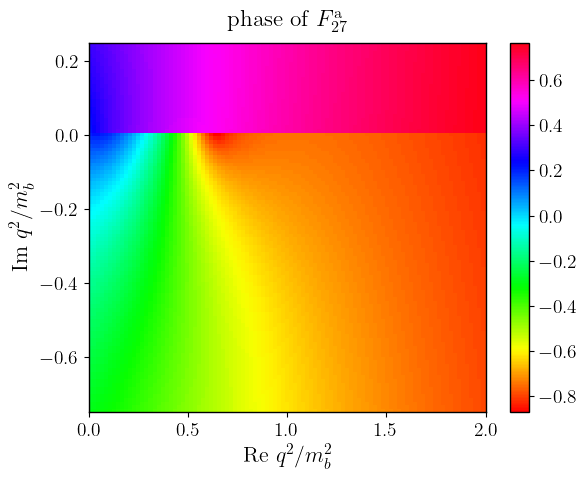

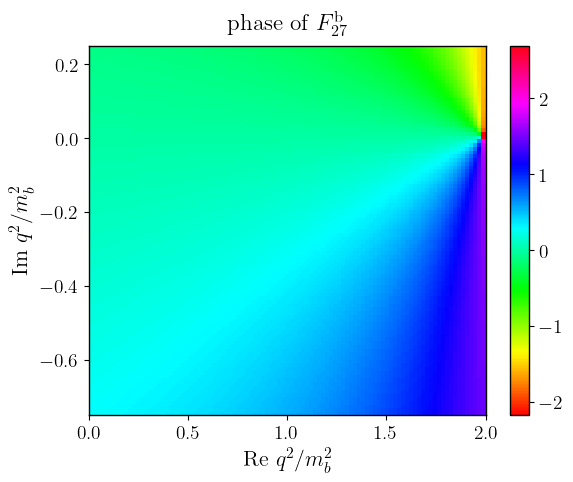

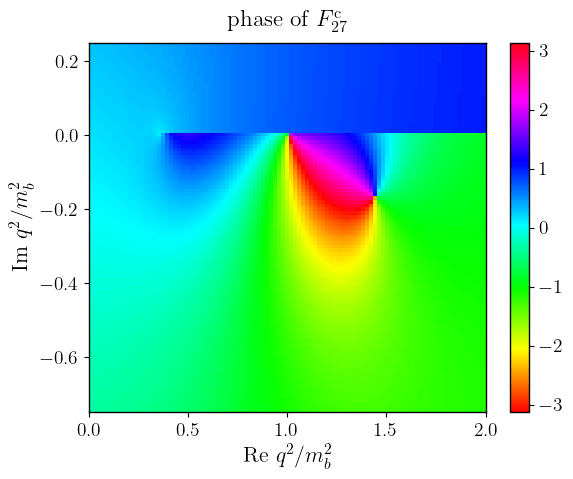

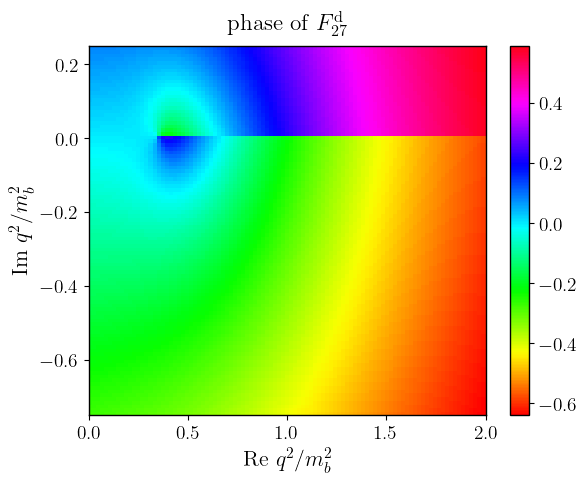

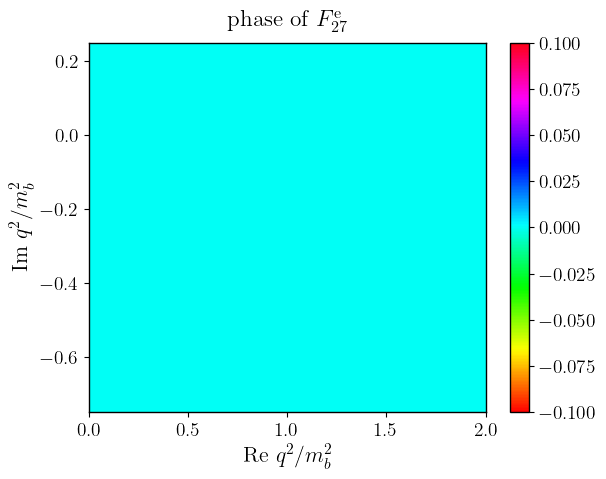

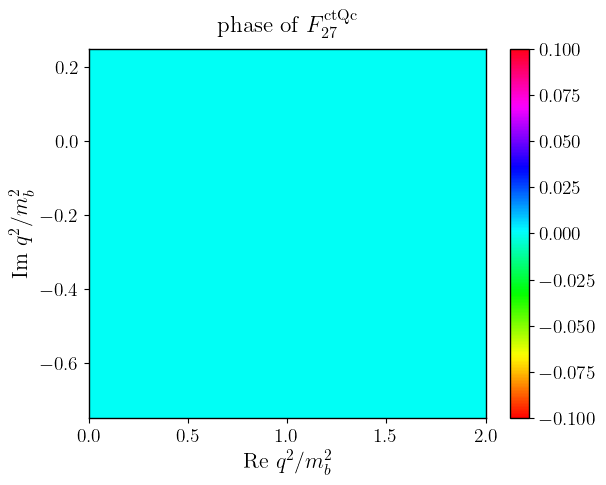

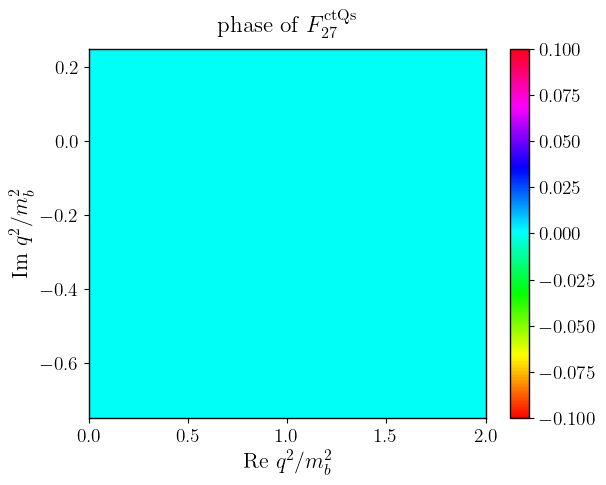

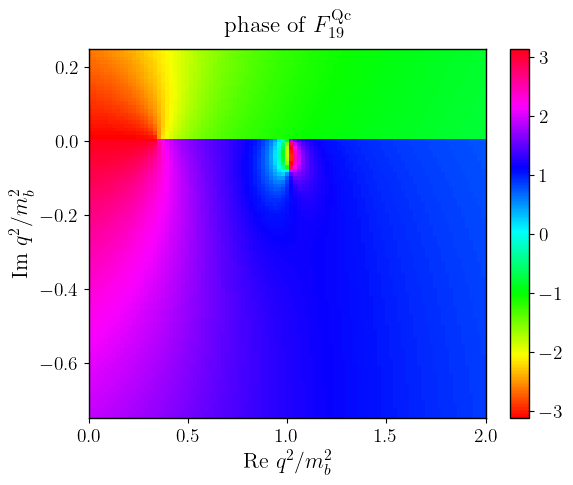

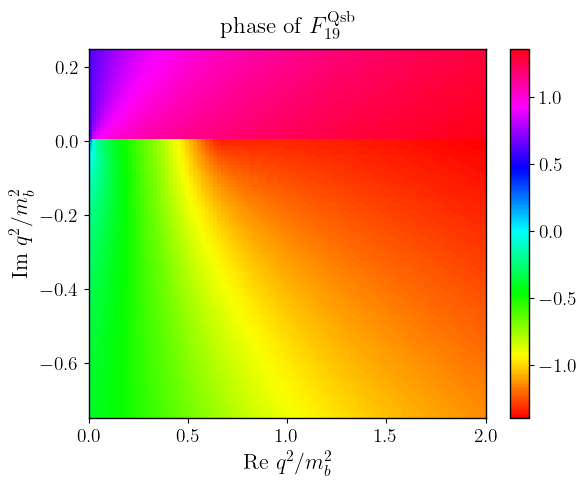

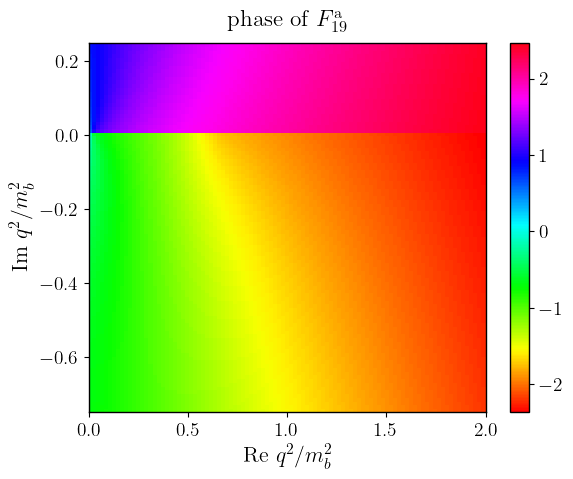

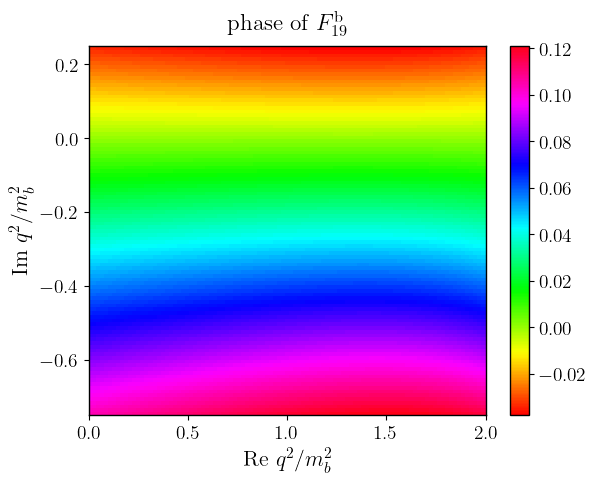

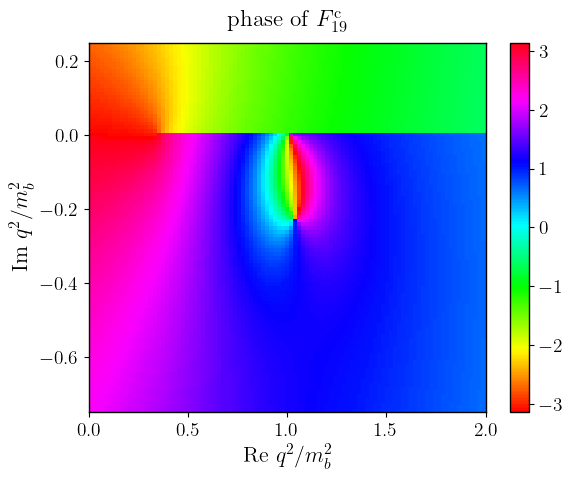

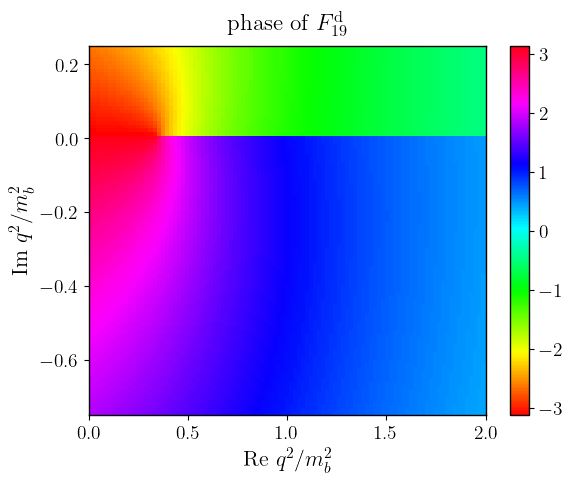

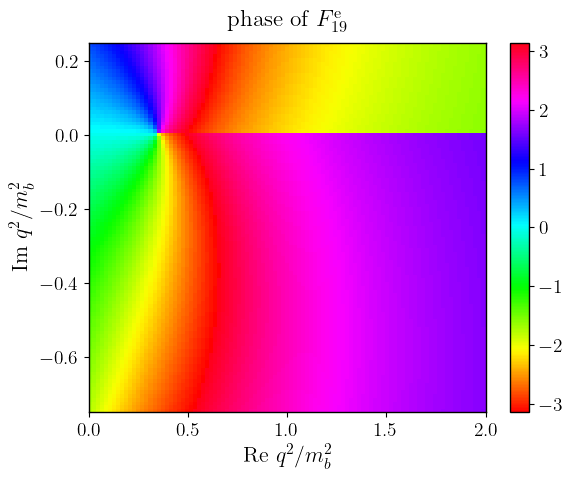

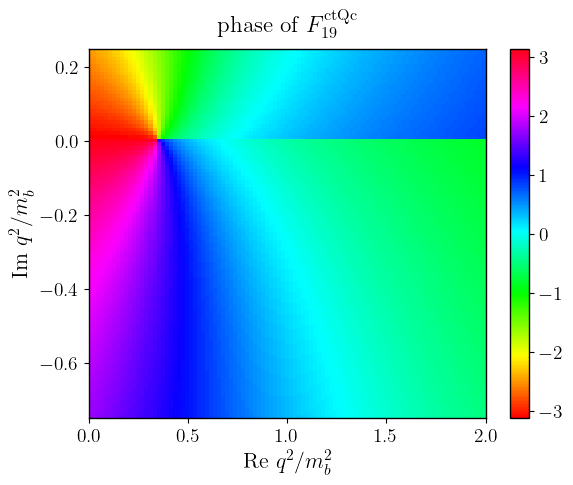

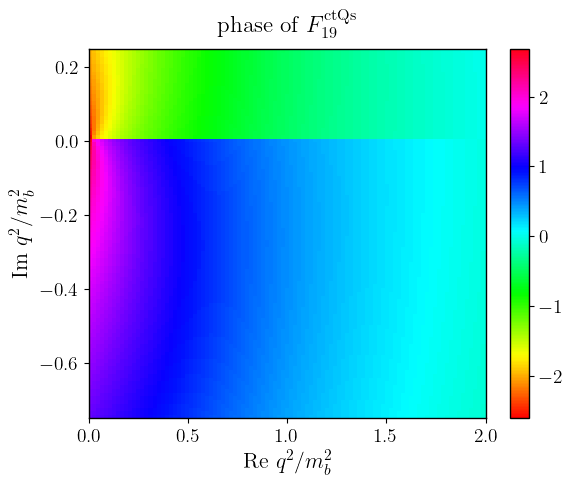

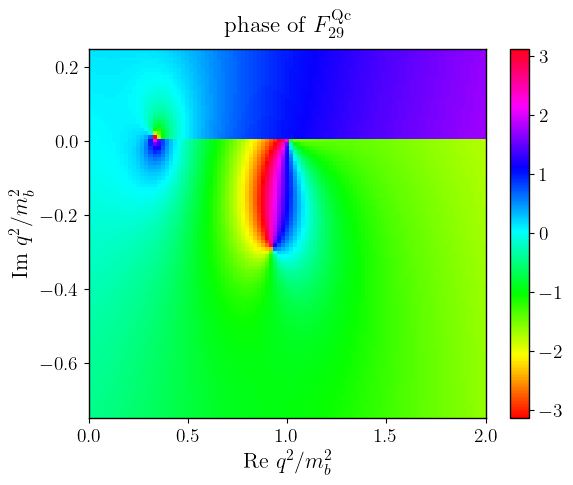

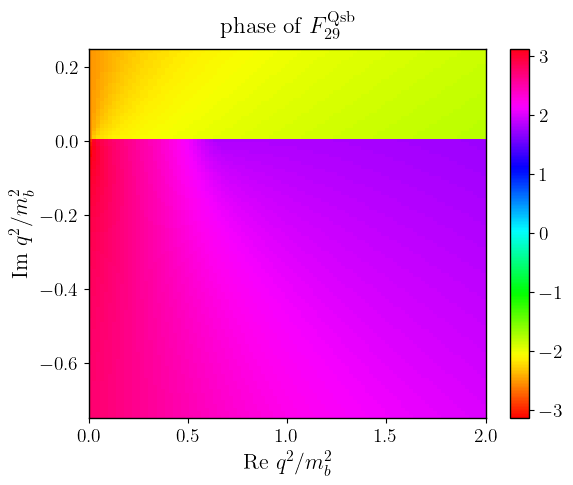

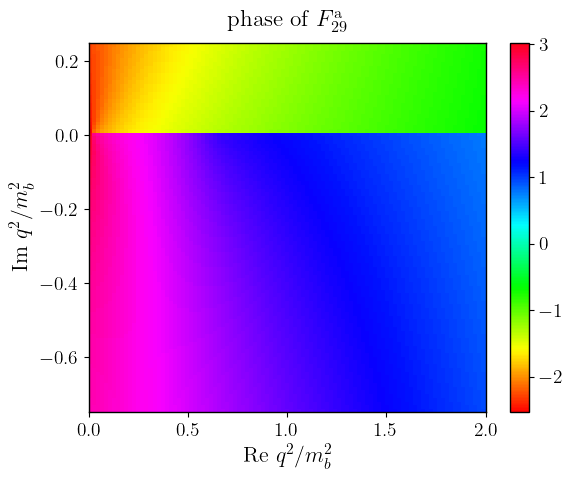

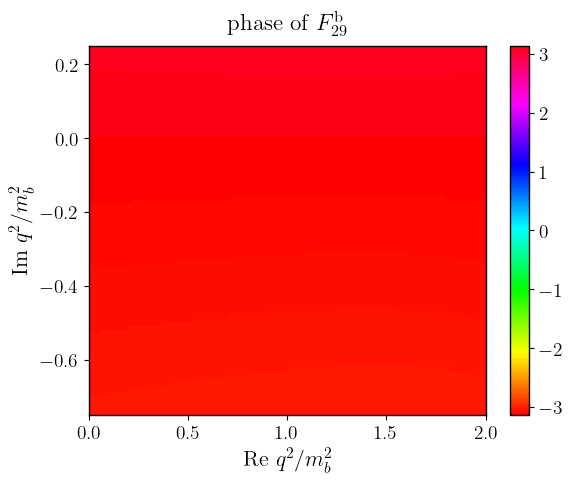

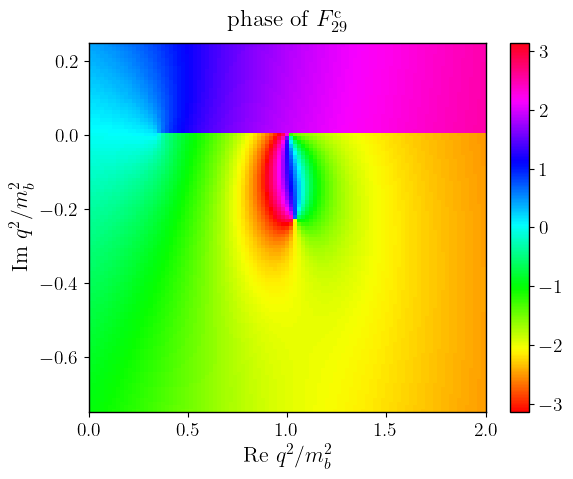

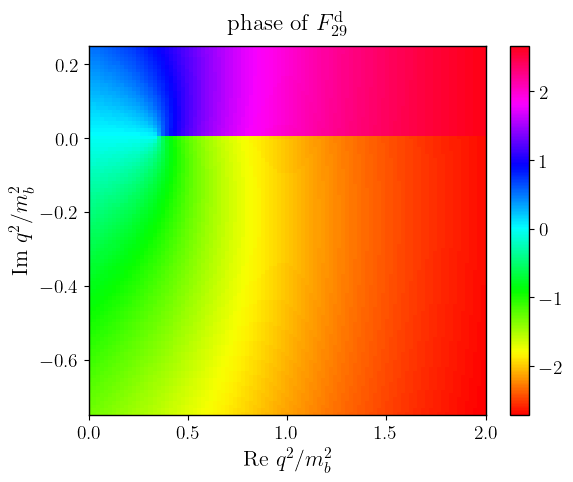

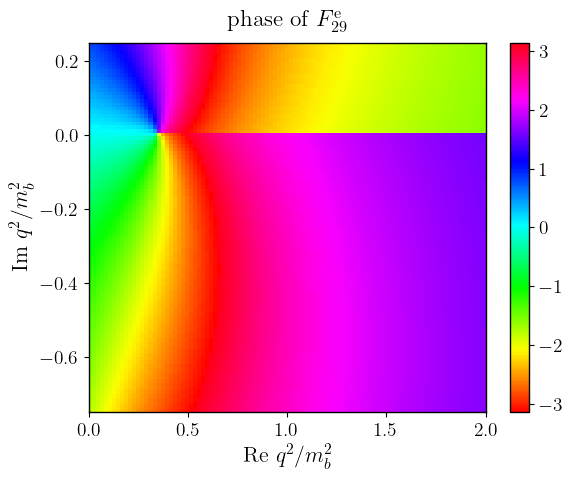

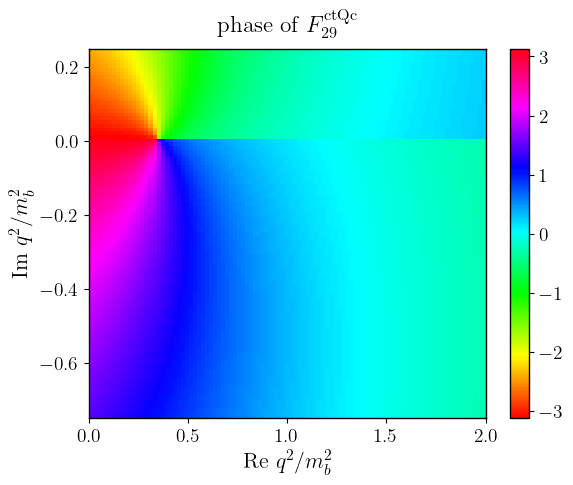

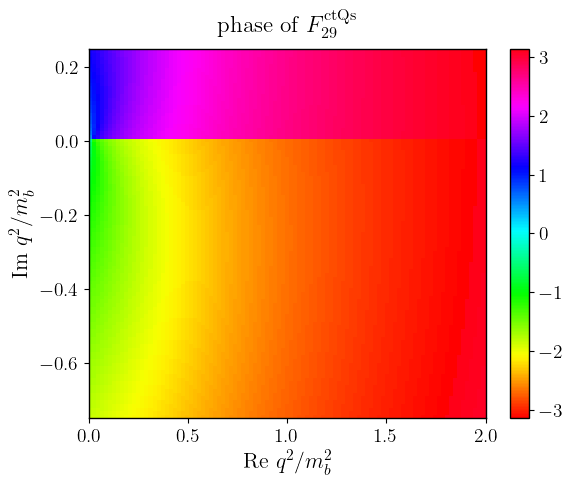

: 

: 

In [ ]:
for i in ["17","27","19","29"]:
        for j in ["Qc", "Qsb", "a", "b", "c", "d", "e", "ctQc", "ctQs"]: #"ctQb"
            plot_2dFF(i, j, num_points=100, real_range=(0.0, 2.0))

#### 3.2.4 Range $s\in [-7.5,-5.5]$

/tmp/ipykernel_2525530/3430960412.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='hsv')


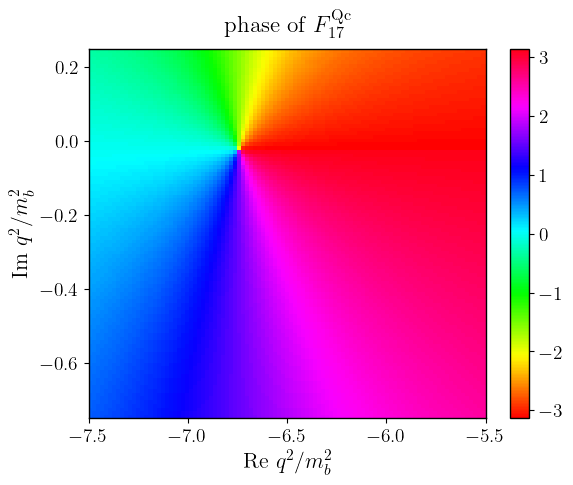

/tmp/ipykernel_2525530/3430960412.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='hsv')


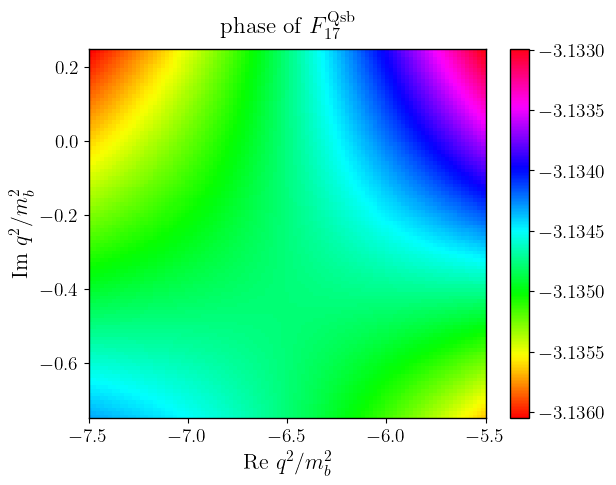

KeyboardInterrupt: 

: 

: 

In [ ]:
for i in ["17","27","19","29"]:
        for j in ["Qc", "Qsb", "a", "b", "c", "d", "e", "ctQc", "ctQs"]: #"ctQb"
            plot_2dFF(i, j, num_points=100, real_range=(-7.5, -5.5))

### 3.3 Plot other functions

/tmp/ipykernel_2525530/671054780.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='viridis')


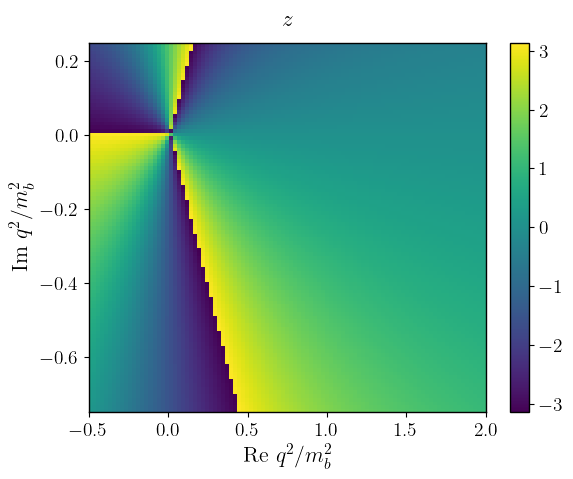

: 

: 

In [ ]:
plot_2dfun(lambda z: pow(z, -3), title="z")

/tmp/ipykernel_2525530/671054780.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='viridis')


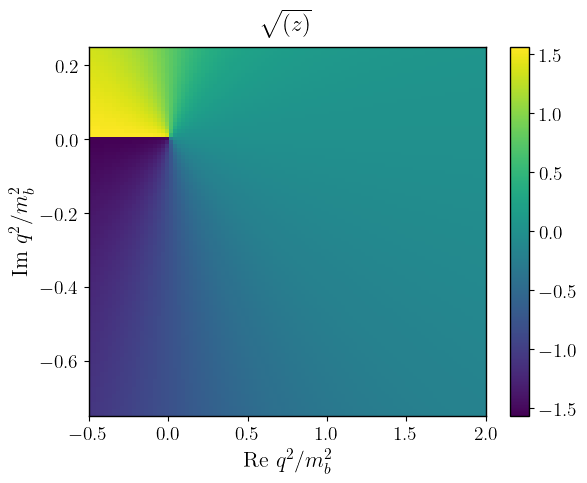

: 

: 

In [ ]:
plot_2dfun(cmath.sqrt, title="\sqrt{{(z)}}")

/tmp/ipykernel_2525530/671054780.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p = ax.pcolor(RealParts, ImagParts, Z, cmap='viridis')


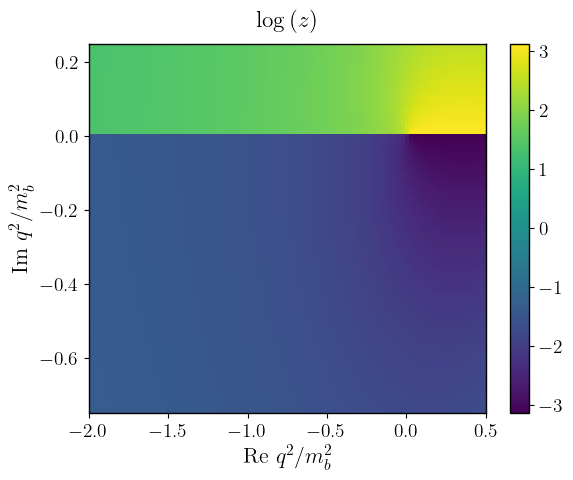

: 

: 

In [ ]:
plot_2dfun(cmath.log, title="\log{{(z)}}", real_range=(-2, 0.5))

## 9 Old stuff

In [ ]:
def plot_2dFF(FF_name, diag_name, real_range=(-0.5, 2.0), imag_range=(-0.75, 0.25), num_points=100, part=np.angle):
    RealParts = np.linspace(real_range[0], real_range[1], num_points)
    ImagParts = np.linspace(imag_range[0], imag_range[1], num_points)
    #X, Y = np.meshgrid(RealParts, ImagParts)

    Z = np.array([[part(FF(FF_name, diag_name, x, y)) for y in ImagParts] for x in RealParts]).T

    fig, ax = plt.subplots()

    p = ax.pcolor(RealParts, ImagParts, Z, cmap='inferno')
    fig.colorbar(p, ax=ax)
    ax.set_xlabel(fr'Re $q^2/m_b^2$')
    ax.set_ylabel(fr'Im $q^2/m_b^2$')
    ax.set_title(fr'phase of $F_{{{FF_name}}}^{{\mathrm{{{diag_name}}}}}$')

    # save plot 
    real_range_str = f'{real_range[0]:.2f}_{real_range[1]:.2f}'.replace('.', 'p')
    if not os.path.exists(f'plots/{real_range_str}'):
        os.makedirs(f'plots/{real_range_str}')
    
    plot_filename = f'plots/{real_range_str}/phase_F{FF_name}_{diag_name}.png'
    plt.savefig(plot_filename)

    plt.show()

: 

: 